## Evaluate resilience of CFCNN against aberrations

In this notebook, we study how various optical aberrations influence the reconstruction quality of the CFCNN.
We study, namely, astigmatism, coma, spherical aberration, and defocus. We use a vector model (placed in `psf_toolbox_v3.py`) and Zernike polynomials to describe the aberrations. We study the behavior of circular polarization.

This notebook requires the following pre-computed data files:
* `data/cnn_output_single_psf.h5`
* `data/cnn_output_star.h5`

These files can be generated by the script `process_inputs_cnn.py`.

In [13]:
## Import modules and define metrics

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from scipy.stats import entropy
import h5py

# ---------- Metrics ----------
def norm(a):
    asu = a - np.min(a)
    norm = np.sum(asu)    
    if norm == 0:
        return np.zeros_like(a)
    return asu / norm

def norm_stack(stack):
    return np.array([norm(img) + 1e-10 for img in stack])

def MAE(imA, imB, blur=2):
    imAn = norm(ndi.gaussian_filter(imA, blur))
    imBn = norm(ndi.gaussian_filter(imB, blur))
    return np.mean(np.abs(imAn.ravel() - imBn.ravel()))

def KLD(im_test, im_ref, blur=2, prevent_infty=True):
    imAn = norm(ndi.gaussian_filter(im_test, blur).ravel())
    if prevent_infty:
        imAn += 1e-10
    imBn = norm(ndi.gaussian_filter(im_ref, blur).ravel())
    return entropy(imBn / np.sum(imBn), imAn / np.sum(imAn), base=2)

# ---------- Parameters ----------
BLUR = 2
f_metrics = {
   'MAE': lambda x, y: MAE(x, y, BLUR),
   'KLD': lambda x, y: KLD(x, y, BLUR) 
}

#studied abberations
SUFFIXES = ['ast', 'coma_x', 'sph', 'def']

In [14]:
# Load and evaluate test data for a single PSF.

fn_input = 'data/cnn_output_single_psf.h5'
transformed_stacks = {}

with h5py.File(fn_input, 'r') as h5f:
    gt_image = np.array(h5f['reference'])
    gt_image = np.roll(gt_image, (-1,-1), axis=(0,1))
    abber_size = np.array(h5f['abberation_size']) #range of abberation is the same for all datasets, hence we load any of them and use it for all.
    
    for suffix in SUFFIXES:
        key = f'A_{suffix}'
        transformed_stacks[key] = np.array(h5f[key][:,:,:,0])        

#save metrics for star
with h5py.File('single_psf_metrics.h5', 'w') as h5f:
    dset_aber_size = h5f.create_dataset('abberation_size', data = abber_size) 
    dset_aber_size.attrs.create('unit', 'lambda')    
    
    for key in transformed_stacks:
        for mkey, metric_fn in f_metrics.items():
            _key = f'{key}/{mkey}'
            print(_key)
            metric_values = np.array([metric_fn(im, gt_image) for im in transformed_stacks[key]])
            h5f.create_dataset(_key, data = metric_values)
            

A_ast/MAE
A_ast/KLD
A_coma_x/MAE
A_coma_x/KLD
A_sph/MAE
A_sph/KLD
A_def/MAE
A_def/KLD


In [15]:
# Load and evaluate test data for a star pattern.

fn_input = 'data/cnn_output_star.h5'
transformed_stacks = {}

with h5py.File(fn_input, 'r') as h5f:
    gt_image = np.array(h5f['reference'])
    #compensate systematic shift of CNN
    gt_image = np.roll(gt_image, (1,0), axis=(0,1))
    abber_size = np.array(h5f['param_A_ast']) #range of abberation is the same for all datasets, hence we load any of them and use it for all.
    
    for suffix in SUFFIXES:
        key = f'A_{suffix}'
        transformed_stacks[key] = np.array(h5f[key][:,:,:,0])        

#save metrics for star
with h5py.File('aber_star_metrics_cnn.h5', 'w') as h5f:
    dset_aber_size = h5f.create_dataset('abberation_size', data = abber_size) 
    dset_aber_size.attrs.create('unit', 'lambda')    
    
    for key in transformed_stacks:
        for mkey, metric_fn in f_metrics.items():
            _key = f'{key}/{mkey}'
            print(_key)
            metric_values = np.array([metric_fn(im, gt_image) for im in transformed_stacks[key]])
            h5f.create_dataset(_key, data = metric_values)    
            

A_ast/MAE
A_ast/KLD
A_coma_x/MAE
A_coma_x/KLD
A_sph/MAE
A_sph/KLD
A_def/MAE
A_def/KLD


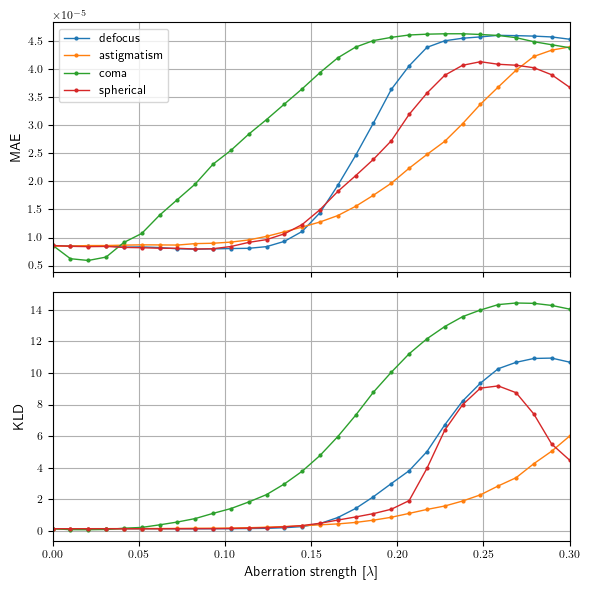

In [17]:
# Plot results for star pattern

labels = {
    'A_def' : 'defocus',
    'A_ast' : 'astigmatism',
    'A_coma_x' : 'coma',
    'A_sph' : 'spherical',    
}

metrics = {}

with h5py.File('aber_star_metrics_cnn.h5', 'r') as h5f:
    abber_size = np.array(h5f['abberation_size'])
    for dkey in labels:
        for mkey in ['MAE', 'KLD']:
            _key = f'{dkey}/{mkey}'
            metrics[_key] = np.array(h5f[_key])

    
fif, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

for i, dkey in enumerate(labels.keys()):    
    for j, mkey in enumerate(['MAE', 'KLD']):        
        _key = f'{dkey}/{mkey}'
        ax[j].plot(abber_size, metrics[_key], ".-", label=labels[dkey])

for j, mkey in enumerate(['MAE', 'KLD']):
    ax[j].set_ylabel(mkey)
    ax[j].grid(True)

ax[0].legend()
ax[-1].set_xlabel(r'Aberration strength [$\lambda$]')
ax[-1].set_xlim(0.0, 0.3)  
plt.tight_layout()
# plt.savefig('MAE_multiple_aberrations.png')
plt.show()

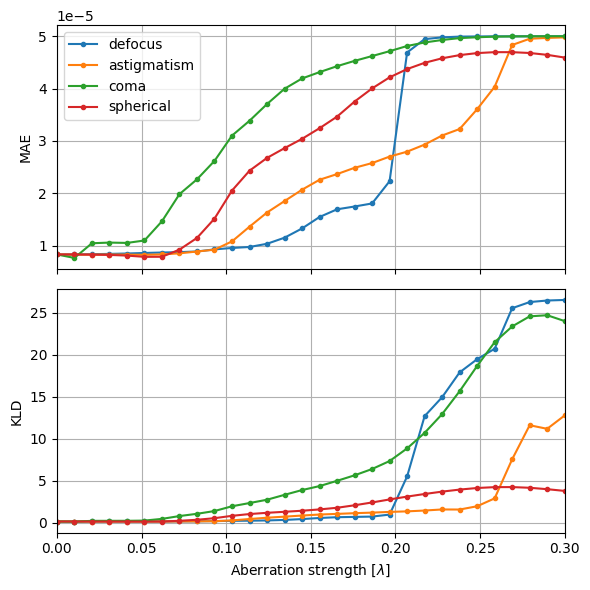

In [8]:
# Plot results for a signle PSF

labels = {
    'A_def' : 'defocus',
    'A_ast' : 'astigmatism',
    'A_coma_x' : 'coma',
    'A_sph' : 'spherical',    
}

metrics = {}

with h5py.File('single_psf_metrics.h5', 'r') as h5f:
    abber_size = np.array(h5f['abberation_size'])
    for dkey in labels:
        for mkey in ['MAE', 'KLD']:
            _key = f'{dkey}/{mkey}'
            metrics[_key] = np.array(h5f[_key])

    
fif, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

for i, dkey in enumerate(labels.keys()):    
    for j, mkey in enumerate(['MAE', 'KLD']):        
        _key = f'{dkey}/{mkey}'
        ax[j].plot(abber_size, metrics[_key], ".-", label=labels[dkey])

for j, mkey in enumerate(['MAE', 'KLD']):
    ax[j].set_ylabel(mkey)
    ax[j].grid(True)
    
ax[0].legend()
ax[-1].set_xlabel(r'Aberration strength [$\lambda$]')
ax[-1].set_xlim(0.0, 0.3)  
plt.tight_layout()
# plt.savefig('MAE_multiple_aberrations.png')
plt.show()

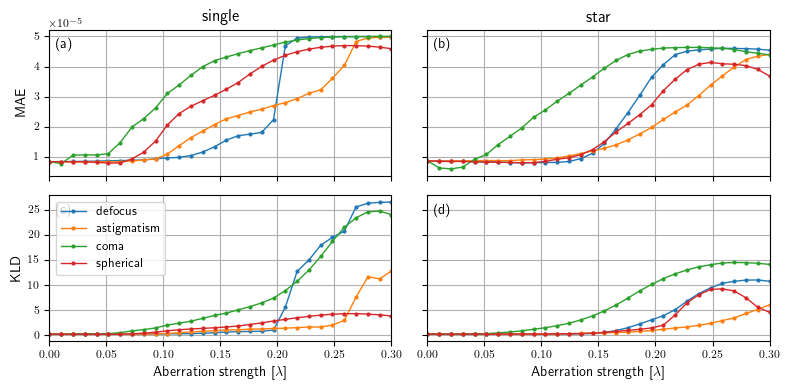

In [18]:
# Compare results

labels = {
    'A_def' : 'defocus',
    'A_ast' : 'astigmatism',
    'A_coma_x' : 'coma',
    'A_sph' : 'spherical',    
}

metrics = {}
cases = ('single', 'star')
files = {'single' : 'single_psf_metrics.h5', 'star' : 'aber_star_metrics_cnn.h5'}

for fn in cases:
    with h5py.File(files[fn], 'r') as h5f:
        abber_size = np.array(h5f['abberation_size'])
        for dkey in labels:
            for mkey in ['MAE', 'KLD']:
                _key = f'{dkey}/{mkey}'
                metrics[f'{fn}/{_key}'] = np.array(h5f[_key])


panels = 'abcd'
fig, ax = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey='row')

for k, fn in enumerate(cases):
    for i, dkey in enumerate(labels.keys()):    
        for j, mkey in enumerate(['MAE', 'KLD']):        
            _key = f'{fn}/{dkey}/{mkey}'
            ax[j, k].plot(abber_size, metrics[_key], ".-", label=labels[dkey])
            if i == 0:
                ax[j, k].text(0.02, 0.87, f'({panels[k+2*j]})', transform=ax[j, k].transAxes)
    
    for j, mkey in enumerate(['MAE', 'KLD']):        
        ax[j, k].grid(True)
        if k==0:
            ax[j, k].set_ylabel(mkey)

ax[1,0].legend()
ax[-1,0].set_xlabel(r'Aberration strength [$\lambda$]')
ax[-1,1].set_xlabel(r'Aberration strength [$\lambda$]')
ax[-1,0].set_xlim(0.0, 0.3)  
ax[-1,1].set_xlim(0.0, 0.3)  
ax[0,0].set_title('single')
ax[0,1].set_title('star')
plt.tight_layout()
plt.savefig('abberation_plot_for_reference.png')
plt.show()

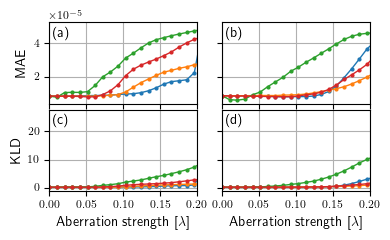

In [19]:
# Save figure for manuscript

labels = {
    'A_def' : 'defocus',
    'A_ast' : 'astigmatism',
    'A_coma_x' : 'coma',
    'A_sph' : 'spherical',    
}

metrics = {}
cases = ('single', 'star')
files = {'single' : 'single_psf_metrics.h5', 'star' : 'aber_star_metrics_cnn.h5'}

for fn in cases:
    with h5py.File(files[fn], 'r') as h5f:
        abber_size = np.array(h5f['abberation_size'])
        for dkey in labels:
            for mkey in ['MAE', 'KLD']:
                _key = f'{dkey}/{mkey}'
                metrics[f'{fn}/{_key}'] = np.array(h5f[_key])


plt.rcParams.update({
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.right': True,
    'axes.spines.top': True,
    'xtick.bottom': True,
    'xtick.labelbottom': True,
    'ytick.left': True,
    'ytick.labelleft': True,
    'lines.linewidth': 1,
    'lines.markersize' : 4,
    'font.size': 11,
    'text.usetex' : True,    
    'font.size': 10,         # Default font size for all text
    'axes.labelsize': 10,    # Labels (x and y axes)
    'xtick.labelsize': 8,    # Tick labels on x-axis
    'ytick.labelsize': 8,    # Tick labels on y-axis
    'legend.fontsize': 9,    # Legend font size
})

panels = 'abcd'
fig, ax = plt.subplots(2, 2, figsize=(4, 2.5), sharex=True, sharey='row')

for k, fn in enumerate(cases):
    for i, dkey in enumerate(labels.keys()):    
        for j, mkey in enumerate(['MAE', 'KLD']):        
            _key = f'{fn}/{dkey}/{mkey}'
            ax[j, k].plot(abber_size, metrics[_key], ".-", label=labels[dkey])
            if i == 0:
                ax[j, k].text(0.025, 0.82, f'({panels[k+2*j]})', transform=ax[j, k].transAxes)
    
    for j, mkey in enumerate(['MAE', 'KLD']):        
        ax[j, k].grid(True)
        if k==0:
            ax[j, k].set_ylabel(mkey)

ax[-1,0].set_xlabel(r'Aberration strength [$\lambda$]')
ax[-1,1].set_xlabel(r'Aberration strength [$\lambda$]')
ax[-1,0].set_xlim(0.0, 0.2)  
ax[-1,1].set_xlim(0.0, 0.2)  
# ax[0,0].set_title('single')
# ax[0,1].set_title('star')
plt.tight_layout()
plt.subplots_adjust(wspace=0.17, hspace=0.07)
plt.savefig('abberation_plot_both.pdf')
plt.show()

## Evaluate reconstruction fidelity versus NA

In [27]:
# Load and evaluate test data for a star pattern.

fn_input = 'data/cnn_output_psf_NA.h5'
transformed_stacks = {}

with h5py.File(fn_input, 'r') as h5f:
    gt_image = np.array(h5f['imggt'])
    #compensate systematic shift of CNN by shifting the GT image
    gt_image = np.roll(gt_image, (1,1), axis=(0,1))
    NA_values = np.array(h5f['NA_values']) #range numerical apertures
    images = np.array(h5f['psfs'])[:,:,:,0]


    
    
# #save metrics for star
with h5py.File('NA_metrics_cnn.h5', 'w') as h5f:
    dset_na_values = h5f.create_dataset('NA_values', data = NA_values)    
    key = 'NA'
    for mkey, metric_fn in f_metrics.items():
        _key = f'{key}/{mkey}'
        print(_key)
        metric_values = np.array([metric_fn(im, gt_image) for im in images])        
        h5f.create_dataset(_key, data = metric_values)
            

NA/MAE
NA/KLD


NA/MAE
NA/KLD


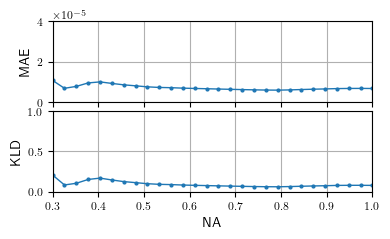

In [41]:
# Save figure for manuscript

metrics = {}

with h5py.File('NA_metrics_cnn.h5', 'r') as h5f:
    NA_values = np.array(h5f['NA_values'])
    key = 'NA'
    for mkey in ['MAE', 'KLD']:
        _key = f'{key}/{mkey}'
        print(_key)
        metrics[_key] = np.array(h5f[_key])


plt.rcParams.update({
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.right': True,
    'axes.spines.top': True,
    'xtick.bottom': True,
    'xtick.labelbottom': True,
    'ytick.left': True,
    'ytick.labelleft': True,
    'lines.linewidth': 1,
    'lines.markersize' : 4,
    'font.size': 11,
    'text.usetex' : True,    
    'font.size': 10,         # Default font size for all text
    'axes.labelsize': 10,    # Labels (x and y axes)
    'xtick.labelsize': 8,    # Tick labels on x-axis
    'ytick.labelsize': 8,    # Tick labels on y-axis
    'legend.fontsize': 9,    # Legend font size
})

panels = 'ab'
fig, ax = plt.subplots(2, 1, figsize=(4, 2.5), sharex=True, sharey='row')
ax = ax.reshape((2,1))

k = 0
for j, mkey in enumerate(['MAE', 'KLD']):        
    _key = f'{key}/{mkey}'
    ax[j, k].plot(NA_values, metrics[_key], ".-")
    if i == 0:
        ax[j, k].text(0.025, 0.82, f'({panels[k+2*j]})', transform=ax[j, k].transAxes)

for j, mkey in enumerate(['MAE', 'KLD']):        
    ax[j, k].grid(True)
    if k==0:
        ax[j, k].set_ylabel(mkey)

ax[-1,0].set_xlabel('NA')
ax[-1,0].set_xlim(0.3,1)  
ax[0,0].set_ylim(0e-5,4e-5)  
ax[1,0].set_ylim(0,1)  
# ax[0,0].set_title('single')
# ax[0,1].set_title('star')
plt.tight_layout()
plt.subplots_adjust(wspace=0.17, hspace=0.12)
plt.savefig('NA_plot.pdf')
plt.show()